# Test Model with Gaussian Walk
Aim here is to test whether modeling team strength as a Gaussian walk makes any sense

## imports

In [1]:
import numpy as np
import scipy as sp
import pandas as pd
import pymc3 as pm
import theano.tensor as tt
%matplotlib inline
import matplotlib.pyplot as plt

## Create data generators for testing

In [2]:
# to keep in mind:   tau = 1 / sigma^2 = sigma**-2
#                  sigma = sqrt(1/tau) = np.sqrt(tau)
np.random.seed(9)
home_rv      = 0.1
intercept_rv = 2.0
tau_atts_home = .10
tau_atts_away = .11
tau_defs_home = .12
tau_defs_away = .13

## Create my own Gaussian random walkers

In [3]:

class MyGaussianRandomWalk():
    def __init__(self, std, walk=True):
        self.mu = 0
        self.mu_old = 0
        self.rho = .95
        self.std = std
        self.walk = walk
        
    def rvs(self,n=1):
        return np.array([self.rv_generator() for i in range(n)])
        
    def rv_generator(self):
        # unpack
        mu = self.mu - self.mu_old
        std = self.std
        rho = self.rho
        
        rv = sp.stats.norm(rho*mu, std).rvs()
        if self.walk:
            self.mu_old = self.mu
            self.mu = rv
        return rv
    
atts_home_rv = MyGaussianRandomWalk(tau_atts_home, False)
atts_away_rv = MyGaussianRandomWalk(tau_atts_away, False)
defs_home_rv = MyGaussianRandomWalk(tau_defs_home, False)
defs_away_rv = MyGaussianRandomWalk(tau_defs_away, False)

In [4]:
atts_home_rv.std

0.1

## Score parameter

In [5]:
#def home_theta(intercept, home, atts, defs, n=1):
#    theta = np.exp(intercept.rvs(n) + home.rvs(n) + atts.rvs(n) + defs.rvs(n))
#    return np.array([sp.stats.poisson(itheta).rvs() for itheta in theta])
#def away_theta(intercept, atts, defs, n=1):
#    theta = np.exp(intercept.rvs(n)  + atts.rvs(n) + defs.rvs(n))
#    return np.array([sp.stats.poisson(itheta).rvs() for itheta in theta])
#
def pts_rvs(intercept, home, atts, defs, n=1):
    theta = np.exp(intercept + home + atts.rvs(n) + defs.rvs(n))
    return np.array([sp.stats.poisson(itheta).rvs() for itheta in theta])

# Simulate data

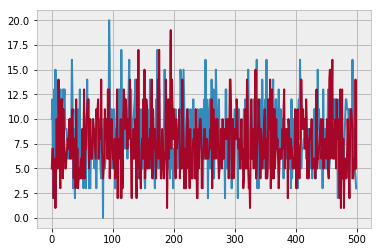

In [6]:
n = 500
home_yds_rv  = pts_rvs(intercept_rv, home_rv, atts_home_rv, defs_away_rv,n)
away_yds_rv  = pts_rvs(intercept_rv,       0, atts_away_rv, defs_home_rv,n)
plt.plot(home_yds_rv)
plt.plot(away_yds_rv)
plt.show()

##  Define model

In [7]:
#from pymc3.distributions.timeseries import GaussianRandomWalk
model = pm.Model()
with model:
    # global model parameters
    home       = pm.Normal('home',      0, tau=.001)
    tau_att    = pm.Gamma('tau_att',   .2, .2)
    tau_def    = pm.Gamma('tau_def',   .2, .2)
    intercept  = pm.Normal('intercept', 0, tau=.001)
        
    atts_star_offset = pm.Normal('atts_star_offset',
                                mu    = 0,
                                sd    = 1,
                                shape = 2)
    
    atts_star  = pm.Deterministic('atts_star', atts_star_offset*tt.sqrt(tau_att))

    defs_star_offset = pm.Normal('defs_star_offset',
                                mu    = 0,
                                sd   = 1,
                                shape = 2)

    defs_star  = pm.Deterministic('defs_star', defs_star_offset*tt.sqrt(tau_def))

    
    #atts_star  = pm.Normal('atts_star',
    #                  mu    = 0,
    #                  tau   = tau_att,
    #                  shape = 2)
    #
    #defs_star  = pm.Normal('defs_star',
    #                  mu    = 0,
    #                  tau   = tau_def,
    #                  shape = 2)

    #atts_star = pm.GaussianRandomWalk('atts_star',
                #      tau = tau_att,
				#      shape = num_teams)

    ##defs_star = pm.GaussianRandomWalk('defs_star',
				#      tau = tau_def,
				#      shape = num_teams)

    atts       = pm.Deterministic('atts', atts_star_offset - tt.mean(atts_star_offset))
    defs       = pm.Deterministic('defs', defs_star_offset - tt.mean(defs_star_offset))
    home_theta = tt.exp(intercept + home + atts[0] + defs[1])
    away_theta = tt.exp(intercept + atts[1] + defs[0])


## Update with observations

In [8]:
with model:
    # likelihood of observed data
    home_yds = pm.Poisson('home_yds',
                          mu=home_theta,
                          observed=home_yds_rv)
    away_yds = pm.Poisson('away_yds',
                          mu=away_theta,
                          observed=away_yds_rv)


## Sample

In [9]:
#from scipy import optimize
with model:
    start = pm.find_MAP()
    step = pm.NUTS(state=start)
    trace = pm.sample(2000, step, init=start)

Optimization terminated successfully.
         Current function value: 2549.422892
         Iterations: 15
         Function evaluations: 19

100%|██████████| 2000/2000 [03:50<00:00,  8.67it/s]


         Gradient evaluations: 19


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x11b42d8d0>,
        <matplotlib.axes._subplots.AxesSubplot object at 0x11bd3e150>]], dtype=object)

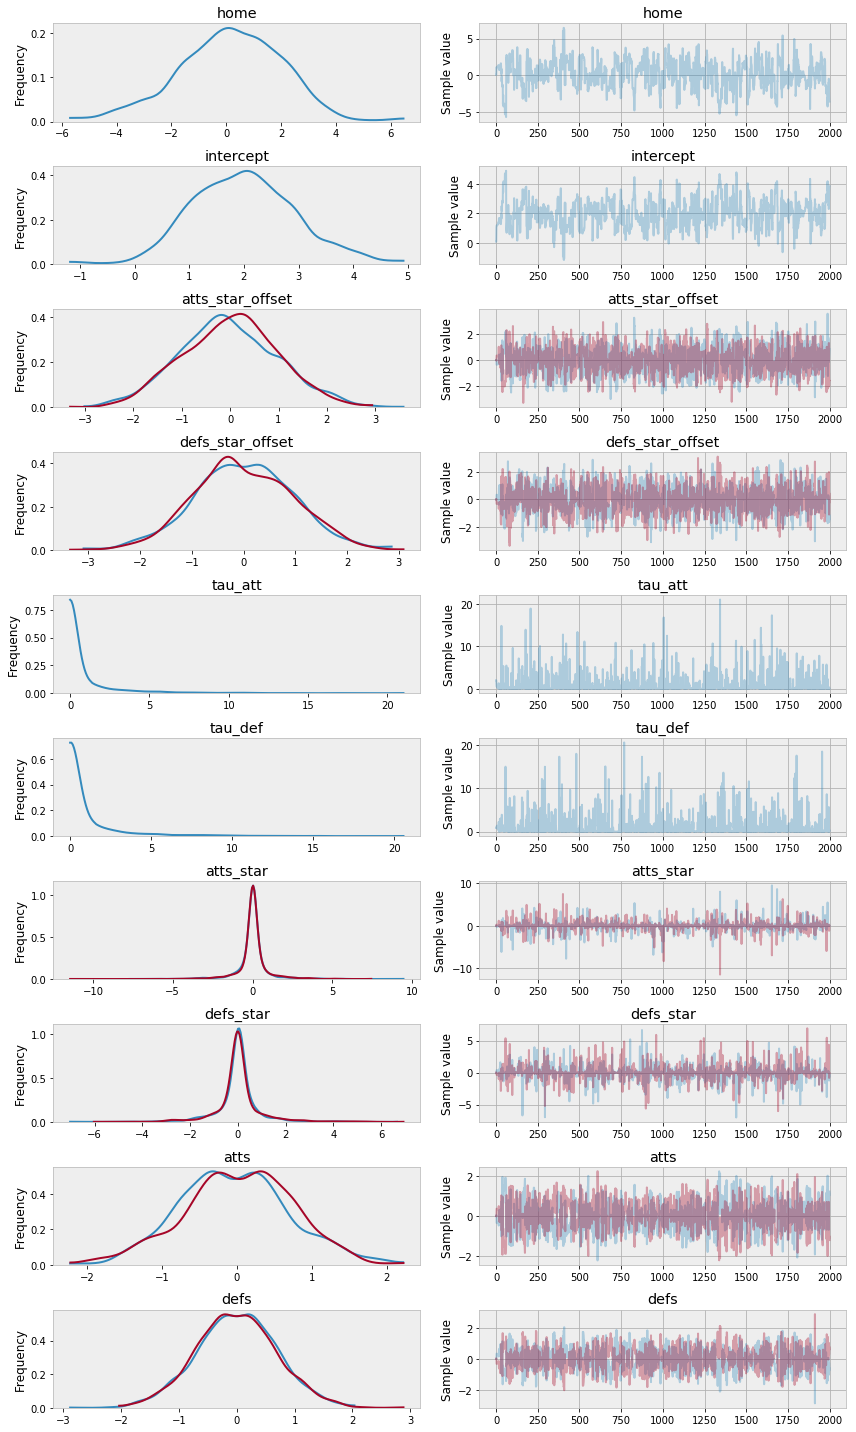

In [10]:
pm.traceplot(trace)

In [11]:
print(start)

{'tau_def_log_': array(0.0), 'tau_att_log_': array(0.0), 'intercept': array(2.028130883504674), 'atts_star_offset': array([-0.00092863,  0.00092863]), 'home': array(0.08539305138294534), 'defs_star_offset': array([ 0.00092863, -0.00092863])}
